In [6]:
!pip install tensorflow



In [4]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import numpy as np


In [5]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.imagenet_utils import decode_predictions
import numpy as np

# Load VGG16 model
model = VGG16(weights='imagenet')

# Generate random data to simulate prediction (just to decode labels)
dummy_data = np.random.random((1, 224, 224, 3))

# Get predictions
preds = model.predict(dummy_data)

# Decode predictions
decoded_predictions = decode_predictions(preds, top=1000)  # Get top 1000 classes

# Print all known classes from ImageNet
class_labels = [class_info[1] for class_info in decoded_predictions[0]]
print(class_labels)


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 662s 1us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
['mosquito_net', 'toilet_tissue', 'envelope', 'shower_curtain', 'tray', 'toilet_seat', 'photocopier', 'Band_Aid', 'paper_towel', 'ballpoint', 'carton', 'Petri_dish', 'electric_fan', 'binder', 'wing', 'water_snake', 'dishwasher', 'cockroach', 'handkerchief', 'wall_clock', 'refrigerator', 'bathtub', 'book_jacket', 'iPod', 'washer', 'dough', 'modem', 'washbasin', 'tub', 'laptop', 'spatula', 'black_widow', 'measuring_cup', 'fire_screen', 'crib', 'plunger', 'syringe', 'Samoyed', 'vault', 'rule', 'cleaver', 'tick', 'switch', 'radiator', 'lotion', 'soap_dispenser', 'sandbar', 'rubber_eraser', 'whiskey_jug', 'pill_bottle', 'hand_blower', 'nipple', 'stingray', 'wooden_spoon', 'bath_towel', 'projector', 'ladle', 'jersey', 'hamper', 'vase', 'centipede', 'notebook', 'mixing_bowl', 'menu', 'axolotl', 'Maltese_dog', 'airship', 'toaster', 'ringneck_snake', 'letter_op

In [7]:
import json
from tensorflow.keras.utils import get_file

# Download the ImageNet class index
CLASS_INDEX_PATH = 'https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json'
class_index_file = get_file('imagenet_class_index.json', CLASS_INDEX_PATH)

# Load the class index file
with open(class_index_file) as f:
    class_index = json.load(f)

# Print all known classes
for class_id, class_info in class_index.items():
    print(f"Class ID: {class_id}, Label: {class_info[1]}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
Class ID: 0, Label: tench
Class ID: 1, Label: goldfish
Class ID: 2, Label: great_white_shark
Class ID: 3, Label: tiger_shark
Class ID: 4, Label: hammerhead
Class ID: 5, Label: electric_ray
Class ID: 6, Label: stingray
Class ID: 7, Label: cock
Class ID: 8, Label: hen
Class ID: 9, Label: ostrich
Class ID: 10, Label: brambling
Class ID: 11, Label: goldfinch
Class ID: 12, Label: house_finch
Class ID: 13, Label: junco
Class ID: 14, Label: indigo_bunting
Class ID: 15, Label: robin
Class ID: 16, Label: bulbul
Class ID: 17, Label: jay
Class ID: 18, Label: magpie
Class ID: 19, Label: chickadee
Class ID: 20, Label: water_ouzel
Class ID: 21, Label: kite
Class ID: 22, Label: bald_eagle
Class ID: 23, Label: vulture
Class ID: 24, Label: great_grey_owl
Class ID: 25, Label: European_fire_salamander
Class ID: 26, Label: common_newt
Class ID: 27, Label: eft
Class ID: 28, Label: spotted_salamander
Class ID: 29, Label: axolotl
Class ID: 30, Label: bullfrog
Clas

In [9]:
!pip install Pillow


In [10]:
from PIL import Image


# 1) Feature Extraction

In [11]:
# Import required libraries
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

class1_data = 'datasets\\cats'
class2_data = 'datasets\\dogs'
main_dataset= 'datasets'
# Function to verify images in a folder
def verify_images(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(os.path.join(folder_path, filename))  # Try to open the image
                img.verify()  # Check if the image is valid
            except (IOError, SyntaxError) as e:
                print(f"Image {filename} is corrupted or invalid.")

# Verify images in the dataset folders
verify_images(class1_data)
verify_images(class2_data)

# Load the pre-trained VGG16 model without the top layers (classification layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers so they don't get trained
for layer in base_model.layers:
    layer.trainable = False

# Add new layers for the specific task
x = Flatten()(base_model.output)  # Flatten the output from the base model
x = Dense(128, activation='relu')(x)  # Add a new fully connected layer (NEW ANN)
x = Dense(2, activation='softmax')(x)  # Add the classification layer (2 categories: cats and dogs)

# Build the final model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model with the chosen optimizer, loss function, and metrics
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Prepare the data using ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    main_dataset ,  # Provide the path to your training data
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Train the model on the new data
model.fit(train_generator, epochs=10, steps_per_epoch=100)

# Function to classify a new image
def classify_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Pass the image through the trained model
    prediction = model.predict(img_array)

    # Show the classification result
    if prediction[0][0] > prediction[0][1]:
        print("It's a cat!")
    else:
        print("It's a dog!")



# Display a single image using Matplotlib
def display_image_matplotlib(img_path):
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 62s 1us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,926,338 (68.38 MB)

 Trainable params: 3,211,650 (12.25 MB)

...

Found 11 images belonging to 2 classes.


C:\Users\Ahmed Mohamed\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 384us/step - accuracy: 0.4545 - loss: 0.9476
Epoch 2/10


C:\Users\Ahmed Mohamed\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 222us/step - accuracy: 0.5455 - loss: 4.7182
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 192us/step - accuracy: 1.0000 - loss: 0.0558
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 253us/step - accuracy: 1.0000 - loss: 3.7687e-04
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 212us/step - accuracy: 1.0000 - loss: 0.0135
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 212us/step - accuracy: 0.9091 - loss: 0.1388
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 226us/step - accuracy: 1.0000 - loss: 0.0511
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 263us/step - accuracy: 1.0000 - loss: 0.0045
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 183us/step - accuracy: 1.0000 - loss: 5.2413e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 242us/step - accuracy: 1.0000 - loss: 9.5282e-05


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step
It's a cat!


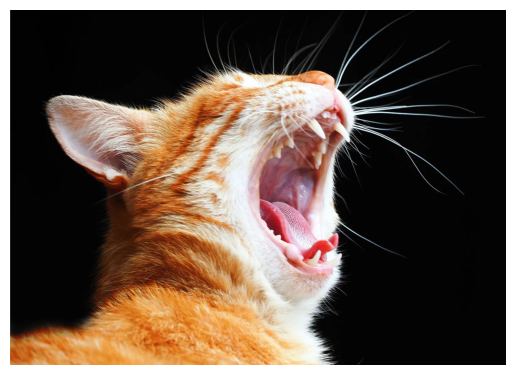

In [35]:
import os

img_path = r"C:\Users\Ahmed Mohamed\Desktop\ALAA\datasets\cats\cat1.jpg"

if not os.path.exists(img_path):
    print(f"🚫 File not found: {img_path}")
else:
    classify_image(img_path)
    display_image_matplotlib(img_path)




# 2) Fine-Tuning
n

In [30]:
# Import required libraries
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Function to verify images in a folder
def verify_images(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(os.path.join(folder_path, filename))  # Try to open the image
                img.verify()  # Check if the image is valid
            except (IOError, SyntaxError) as e:
                print(f"Image {filename} is corrupted or invalid.")

# Verify images in the dataset folders
verify_images(r"C:\Users\Ahmed Mohamed\Desktop\ALAA\datasets\cats")
verify_images(r"C:\Users\Ahmed Mohamed\Desktop\ALAA\datasets\dogs")

# Load the pre-trained VGG16 model without the top layers (classification layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers initially (so they don't get trained in the first phase)
for layer in base_model.layers:
    layer.trainable = False

# Add new layers for the specific task
x = Flatten()(base_model.output)  # Flatten the output from the base model
x = Dense(128, activation='relu')(x)  # Add a new fully connected layer
x = Dense(2, activation='softmax')(x)  # Add the classification layer (2 categories: cats and dogs)

# Build the final model
model = Model(inputs=base_model.input, outputs=x)

# Compile the model for the first phase of training (with frozen layers)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Prepare the data using ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    r'C:\Users\Ahmed Mohamed\Desktop\ALAA\datasets',  # Provide the path to your training data
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Train the model on the new data (with frozen layers)
model.fit(train_generator, epochs=5, steps_per_epoch=100)

# Fine-tuning phase: Unfreeze some layers of the base model
for layer in base_model.layers[-4:]:  # Unfreeze the last 4 layers for fine-tuning
    layer.trainable = True

# Compile the model again with a lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model again (this time with some unfrozen layers)
model.fit(train_generator, epochs=5, steps_per_epoch=100)

# Function to classify a new image
def classify_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Pass the image through the trained model
    prediction = model.predict(img_array)

    # Show the classification result
    if prediction[0][0] > prediction[0][1]:
        print("It's a cat!")
    else:
        print("It's a dog!")

# Display a single image using PIL
def display_image_pil(img_path):
    img = Image.open(img_path)
    img.show()

# Display a single image using Matplotlib
def display_image_matplotlib(img_path):
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()




Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 17,926,338 (68.38 MB)

 Trainable params: 3,211,650 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Found 14 images belonging to 2 classes.
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 202us/step - accuracy: 0.5714 - loss: 0.7712
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 232us/step - accuracy: 0.6429 - loss: 3.0977
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 197us/step - accuracy: 1.0000 - loss: 0.0090
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 242us/step - accuracy: 1.0000 - loss: 0.0028
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 242us/step - accuracy: 1.0000 - loss: 0.0626
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 222us/step - accuracy: 1.0000 - loss: 0.0512
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 217us/step - accuracy: 1.0000 - loss: 0.0136
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 212us/step - accuracy: 1.0000 - loss: 0.0043
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 202us/step - accuracy: 1.0000 - loss: 0.0017
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 212us/step - accuracy: 1.0000 - loss: 7.7446e-04


## Summary:

1. **Image Verification**:  
   First, we verified the images using a verification function.

2. **Loading the Pre-Trained Model**:  
   We loaded the pre-trained **VGG16** model without the top classification layers.

3. **Freezing the Layers**:  
   We froze the original layers to preserve the features learned by the model.

4. **Adding Custom Layers**:  
   We added new layers suited for our specific task (classifying cats and dogs).

5. **Training the Model**:  
   We trained the model using the new dataset.

6. **Fine-Tuning**:  
   We unfroze some layers and performed **Fine-Tuning** to adapt the model further.

7. **Classifying and Displaying a New Image**:  
   Finally, we classified a new image and displayed it using **PIL** and **Matplotlib**.

---

If you have any additional questions or need further clarification or modification to the code, feel free to ask!


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
It's a dog!


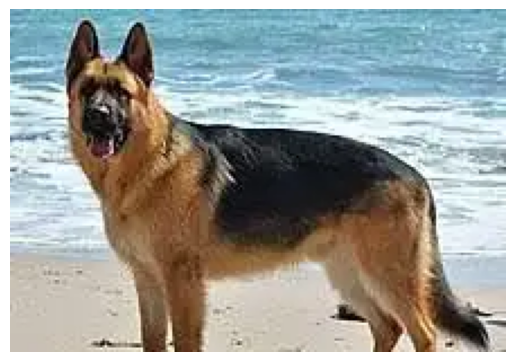

In [33]:
img_path = "C:/Users/Ahmed Mohamed/Desktop/ALAA/datasets/dogs/dog.jpg"


classify_image(img_path)
display_image_matplotlib(img_path)

In [34]:
class1_data = 'datasets\\cats'
class2_data = 'datasets\\dogs'
main_dataset= 'datasets'
# Function to verify images in a folder
def verify_images(folder_path):
    for filename in os.listdir(folder_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(os.path.join(folder_path, filename))  # Try to open the image
                img.verify()  # Check if the image is valid
            except (IOError, SyntaxError) as e:
                print(f"Image {filename} is corrupted or invalid.")

# Verify images in the dataset folders
verify_images(class1_data)
verify_images(class2_data)